<a href="https://colab.research.google.com/github/maxsccavalcante/FabricaSoftware/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Os datasets são:
#### Ao escolher o dataset que você vai trabalhar, copie o path e cole na célula de abetura do arquivo para ter acesso ao dataframe.

*   **Real State Valuation Dataset** — Dataset de Taiwan sobre preços de imóveis, com colunas como distância até estação de metrô, número de lojas de conveniência próximas, latitude, longitude e idade do imóvel — todas numéricas, target também numérico (preço por área).
https://www.kaggle.com/datasets/yasserh/titanic-dataset

*   **Calculate Concrete Strength** — Dataset sobre resistência de concreto, com colunas como quantidade de cimento, água, agregados, idade da mistura — tudo numérico, prevendo a resistência à compressão (target numérico).
https://www.kaggle.com/datasets/uciml/mushroom-classification


In [1]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sklearn
warnings.filterwarnings('ignore')

# Bibliotecas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Configurar estilo para melhores visualizações
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Todas as bibliotecas importadas com sucesso!")
print("Versão do Scikit-learn:", sklearn.__version__)


Todas as bibliotecas importadas com sucesso!
Versão do Scikit-learn: 1.6.1


In [5]:
# Carregue seu dataset aqui
from google.colab import files

uploaded = files.upload()
# Coloque o caminho do arquivo CSV que você baixou do Kaggle entre as aspas abaixo
df = pd.read_csv("Titanic-Dataset.csv")  # TODO: coloque o path do seu arquivo CSV aqui

# Separe suas features (X) e seu target (y)
# X = todas as colunas que serão usadas para prever (menos a coluna target)
# y = a coluna que você quer prever (deve ser numérica, já que é regressão)

X = df.drop(columns=['Survived'])  # TODO: coloque o nome da(s) coluna(s) que NÃO serão usadas como feature (ex: 'preco')
y = df['Survived']  # TODO: coloque o nome da coluna que será o seu target (ex: 'preco')

print("Dataset carregado com sucesso!")
print("Formato:", df.shape)
print(f"Formato do dataset: {X.shape}")
print(f"Número de amostras: {X.shape[0]}")
print(f"Número de features: {X.shape[1]}")
print(f"Faixa da variável target: {y.min():.2f} - {y.max():.2f}")
print(f"Valor médio do target: {y.mean():.2f}")
display(df.head())

Saving Titanic-Dataset.csv to Titanic-Dataset (2).csv
Dataset carregado com sucesso!
Formato: (891, 12)
Formato do dataset: (891, 11)
Número de amostras: 891
Número de features: 11
Faixa da variável target: 0.00 - 1.00
Valor médio do target: 0.38


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [58]:
# Exibir informações básicas sobre nosso dataset
print("=== VISÃO GERAL DO DATASET ===")
print(f"Formato do dataset: {X.shape}")
print(f"Formato do target: {y.shape}")
print("\n=== PRIMEIRAS 5 LINHAS ===")
print("=== VALORES AUSENTES ===")

missing = df.isnull().sum()
print(missing)

print("=== COLUNAS COM VALORES AUSENTES ===")
print(missing[missing > 0])
missing_percent = (df.isnull().sum() / len(df)) * 100

print("=== PORCENTAGEM DE VALORES AUSENTES ===")
print(missing_percent[missing_percent > 0].sort_values(ascending=False))
print(X.head())

df = df.drop(columns=['Cabin'])

=== VISÃO GERAL DO DATASET ===
Formato do dataset: (891, 10)
Formato do target: (891,)

=== PRIMEIRAS 5 LINHAS ===
=== VALORES AUSENTES ===
Survived        0
Pclass          0
Sex             0
Age           177
SibSp           0
Parch           0
Fare            0
Embarked        2
FamilySize      0
IsAlone         0
Title           0
dtype: int64
=== COLUNAS COM VALORES AUSENTES ===
Age         177
Embarked      2
dtype: int64
=== PORCENTAGEM DE VALORES AUSENTES ===
Age         19.865320
Embarked     0.224467
dtype: float64
   Pclass   Age  SibSp  Parch     Fare  FamilySize  IsAlone  Sex_male  \
0       3  22.0      1      0   7.2500           2        0       1.0   
1       1  38.0      1      0  71.2833           2        0       0.0   
2       3  26.0      0      0   7.9250           1        1       0.0   
3       1  35.0      1      0  53.1000           2        0       0.0   
4       3  35.0      0      0   8.0500           1        1       1.0   

   Embarked_Q  Embarked_S  
0

In [59]:
# Limpeza dos dados
print("Formato antes da limpeza:", df.shape)

df = df.drop(columns=['PassengerId', 'Ticket'])

print("Formato depois da limpeza:", df.shape)
print("\nColunas restantes:")
print(df.columns.tolist())

Formato antes da limpeza: (891, 11)


KeyError: "['PassengerId', 'Ticket'] not found in axis"

In [60]:
# Tamanho da família
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Indica se o passageiro estava viajando sozinho
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Título do nome
df['Title'] = df['Name'].str.extract(r',\s*([^.]*)\.')[0]

print("Novas features criadas!")

display(df[['Name', 'SibSp', 'Parch', 'FamilySize', 'IsAlone', 'Title']].head(10))

df = df.drop(columns=['Name'])

KeyError: 'Embarked'

In [29]:
print(df.isnull().sum())
print(df.dtypes)
display(df.head())

Survived        0
Pclass          0
Sex             0
Age           177
SibSp           0
Parch           0
Fare            0
Embarked        2
FamilySize      0
IsAlone         0
Title           0
dtype: int64
Survived        int64
Pclass          int64
Sex            object
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked       object
FamilySize      int64
IsAlone         int64
Title          object
dtype: object


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title
0,0,3,male,22.0,1,0,7.2500,S,2,0,Mr
1,1,1,female,38.0,1,0,71.2833,C,2,0,Mrs
2,1,3,female,26.0,0,0,7.9250,S,1,1,Miss
3,1,1,female,35.0,1,0,53.1000,S,2,0,Mrs
4,0,3,male,35.0,0,0,8.0500,S,1,1,Mr


In [30]:
  print("\n=== RESUMO ESTATÍSTICO ===")
  X.describe()


=== RESUMO ESTATÍSTICO ===


,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [31]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Name         891 non-null    object 
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


In [32]:
print(f"\nValores ausentes nas features: ")
X.isnull().sum().sum()
print(f"Valores ausentes no target: {pd.isnull(y).sum()}")


Valores ausentes nas features: 
Valores ausentes no target: 0


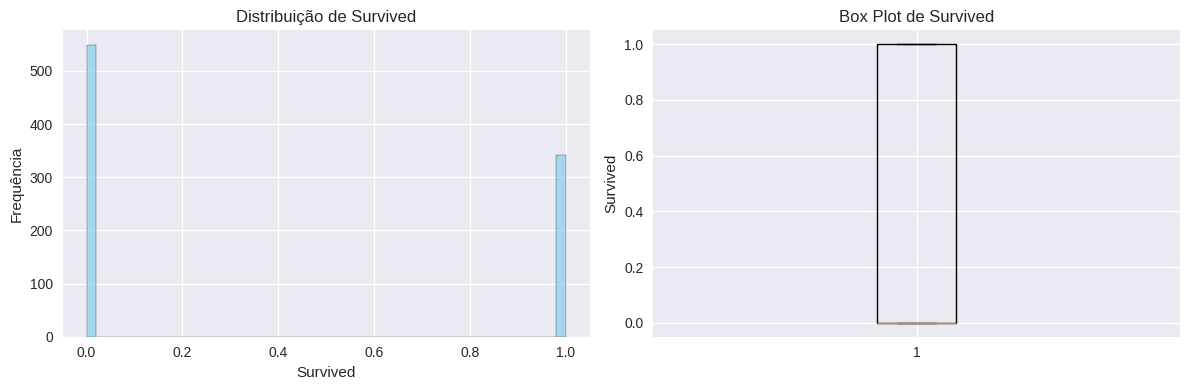

Estatísticas da variável target:
Média: 0.38 
Mediana: 0.00 
Desvio padrão: 0.49 


In [33]:
# TODO: defina o nome do que você está prevendo e a unidade de medida (se houver)
nome_target = "Survived"  # ex: "Preço da Casa", "Nota do Aluno", "Temperatura"
unidade_target = ""  # ex: "milhares de dólares", "pontos", "°C" (deixe "" se não houver unidade)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title(f'Distribuição de {nome_target}')
plt.xlabel(f'{nome_target} ({unidade_target})' if unidade_target else nome_target)
plt.ylabel('Frequência')

plt.subplot(1, 2, 2)
plt.boxplot(y, vert=True)
plt.title(f'Box Plot de {nome_target}')
plt.ylabel(f'{nome_target} ({unidade_target})' if unidade_target else nome_target)

plt.tight_layout()
plt.show()

print(f"Estatísticas da variável target:")
print(f"Média: {y.mean():.2f} {unidade_target}")
print(f"Mediana: {np.median(y):.2f} {unidade_target}")
print(f"Desvio padrão: {y.std():.2f} {unidade_target}")

In [70]:
# Já separamos nossas variáveis, mas vamos confirmar e visualizar a relação
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

print("=== DIVISÃO DOS DADOS ===")

print(f"Dataset original: {X.shape[0]} passageiros")

print(f"\nTreino:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print(f"\nTeste:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

print("=== DISTRIBUIÇÃO DO TARGET ===")

print("Dataset completo:")
print(y.value_counts(normalize=True))

print("\nTreino:")
print(y_train.value_counts(normalize=True))

print("\nTeste:")
print(y_test.value_counts(normalize=True))

idade_mediana = X_train['Age'].median()

print(f"Mediana da idade no conjunto de treino: {idade_mediana:.2f}")

X_train['Age'] = X_train['Age'].fillna(idade_mediana)
X_test['Age'] = X_test['Age'].fillna(idade_mediana)


Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64
Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64
=== DIVISÃO DOS DADOS ===
Dataset original: 891 passageiros

Treino:
X_train: (712, 10)
y_train: (712,)

Teste:
X_test: (179, 10)
y_test: (179,)
=== DISTRIBUIÇÃO DO TARGET ===
Dataset completo:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Treino:
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Teste:
Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64
Mediana da idade no conjunto de treino: 28.00


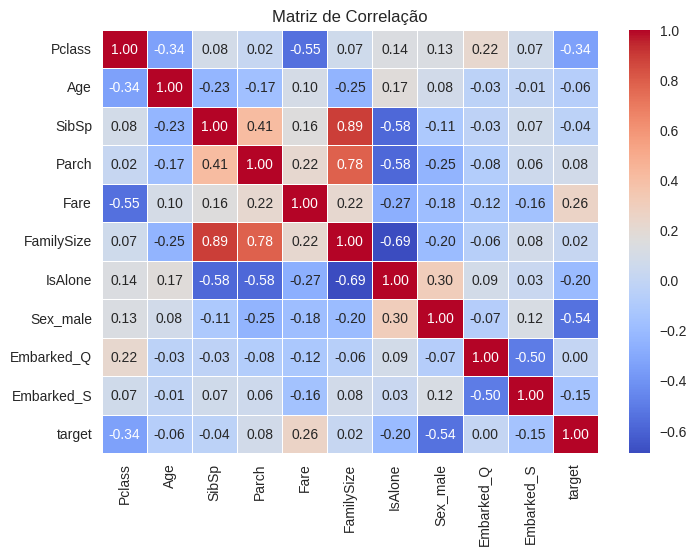

In [55]:
# unimos X e y em um único DataFrame para o cálculo
# Usamos pd.concat para colocar a coluna do target ao lado das outras features

df_para_corr = pd.concat([X, pd.Series(y, name='target')], axis=1)

# matriz de correlação usando o Pandas
matriz_corr = df_para_corr.corr(numeric_only=True)

# visualizamos com o Seaborn (Heatmap)
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlação')
plt.show()

In [64]:
# Dividir os dados em conjuntos de treino e teste
# test_size=0.2 significa 20% para teste, 80% para treino
# random_state=42 garante resultados reproduzíveis (mesma divisão sempre)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("=== RESULTADOS DA DIVISÃO DOS DADOS ===")
print(f"Tamanho do dataset original: {X.shape[0]} amostras")
print(f"Tamanho do conjunto de treino: {X_train.shape[0]} amostras ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} amostras ({X_test.shape[0]/X.shape[0]*100:.1f}%)")

print(f"\nFormato das features de treino: {X_train.shape}")
print(f"Formato do target de treino: {y_train.shape}")
print(f"Formato das features de teste: {X_test.shape}")
print(f"Formato do target de teste: {y_test.shape}")

print(f"\nEstatísticas do target do conjunto de treino:")
print(f"Média: ${y_train.mean():.2f}, Desvio: ${y_train.std():.2f}")
print(f"Estatísticas do target do conjunto de teste:")
print(f"Média: ${y_test.mean():.2f}, Desvio: ${y_test.std():.2f}")
print("✓ Ambos conjuntos têm distribuições similares - boa divisão!")


=== RESULTADOS DA DIVISÃO DOS DADOS ===
Tamanho do dataset original: 891 amostras
Tamanho do conjunto de treino: 712 amostras (79.9%)
Tamanho do conjunto de teste: 179 amostras (20.1%)

Formato das features de treino: (712, 10)
Formato do target de treino: (712,)
Formato das features de teste: (179, 10)
Formato do target de teste: (179,)

Estatísticas do target do conjunto de treino:
Média: $0.38, Desvio: $0.48
Estatísticas do target do conjunto de teste:
Média: $0.41, Desvio: $0.49
✓ Ambos conjuntos têm distribuições similares - boa divisão!


In [65]:

# 1. LIMPEZA DOS DADOS E REMOÇÃO DE TEXTOS
# Incluímos 'Title' e qualquer outra coluna de texto no drop
cols_para_remover = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'Title']
df_clean = df.drop(columns=[col for col in cols_para_remover if col in df.columns], errors='ignore')

# Preenche valores ausentes
if 'Age' in df_clean.columns:
    df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
if 'Embarked' in df_clean.columns:
    df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# Transforma categóricas em números (0 e 1) forçando o tipo float/int
cols_categoricas = [col for col in ['Sex', 'Embarked'] if col in df_clean.columns]
df_encoded = pd.get_dummies(df_clean, columns=cols_categoricas, drop_first=True, dtype=float)

# 2. SEPARAÇÃO DE FEATURES (X) E TARGET (y)
X = df_encoded.drop(columns=['Survived'])
y = df_encoded['Survived']

# 3. DIVISÃO EM TREINO E TESTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. EXIBE ESTATÍSTICAS ANTES DO ESCALONAMENTO
print("=== ANTES DO ESCALONAMENTO ===")
display(X_train.describe())

# 5. ESCALONAMENTO (StandardScaler)
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converte de volta para DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# 6. EXIBE ESTATÍSTICAS APÓS O ESCALONAMENTO
print("\n=== APÓS O ESCALONAMENTO ===")
display(X_train_scaled.describe())

=== ANTES DO ESCALONAMENTO ===


,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S
count,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000
mean,2.330056,29.204129,0.553371,0.379213,32.586276,1.932584,0.602528,0.655899,0.084270,0.740169
std,0.824584,13.007971,1.176404,0.791669,51.969529,1.682525,0.489719,0.475408,0.277987,0.438850
min,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,22.000000,0.000000,0.000000,7.925000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000,1.000000,1.000000,0.000000,1.000000
75%,3.000000,35.000000,1.000000,0.000000,30.500000,2.000000,1.000000,1.000000,0.000000,1.000000
max,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000,1.000000,1.000000,1.000000,1.000000



=== APÓS O ESCALONAMENTO ===


,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S
count,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,712.000000
mean,9.355812e-17,1.746418e-17,1.746418e-17,2.245395e-17,5.363999e-17,-4.989766e-17,1.047851e-16,-9.979533e-18,1.871162e-18,0.000000
std,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00,1.000703
min,-1.614136e+00,-2.214363e+00,-4.707224e-01,-4.793416e-01,-6.274674e-01,-5.546661e-01,-1.231219e+00,-1.380624e+00,-3.033555e-01,-1.687794
25%,-4.005512e-01,-5.542135e-01,-4.707224e-01,-4.793416e-01,-4.748670e-01,-5.546661e-01,-1.231219e+00,-1.380624e+00,-3.033555e-01,-1.687794
50%,8.130337e-01,-9.263364e-02,-4.707224e-01,-4.793416e-01,-3.491435e-01,-5.546661e-01,8.122030e-01,7.243102e-01,-3.033555e-01,0.592489
75%,8.130337e-01,4.458762e-01,3.799232e-01,-4.793416e-01,-4.017244e-02,4.009635e-02,8.122030e-01,7.243102e-01,-3.033555e-01,0.592489
max,8.130337e-01,3.907725e+00,6.334442e+00,7.104908e+00,9.237724e+00,5.392959e+00,8.122030e-01,7.243102e-01,3.296463e+00,0.592489


In [66]:
X_train.shape
X_test.shape

X_train.isnull().sum()
X_test.isnull().sum()

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Survived
0    0.623596
1    0.376404
Name: proportion, dtype: float64
Survived
0    0.586592
1    0.413408
Name: proportion, dtype: float64


In [77]:
# Criar um modelo de Regressão Linear
from sklearn.linear_model import LinearRegression
model = LinearRegression()

print("=== TREINAMENTO DO MODELO ===")
print(f"Modelo criado: {model}")
print(f"Treinando com {X_train_scaled.shape[0]} amostras e {X_train_scaled.shape[1]} features")

# Treinar o modelo com nossos dados de treino escalonados
# É aqui que o modelo aprende a relação entre features e target
model.fit(X_train_scaled, y_train)

print("✓ Treinamento do modelo concluído!")

# Vamos examinar o que o modelo aprendeu
print(f"\n=== PARÂMETROS DO MODELO ===")
print(f"Intercepto (β₀): {model.intercept_:.4f}")
print(f"Coeficientes (β₁...βₙ):")

# Exibir coeficientes para cada feature
for feature, coef in zip(X_train_scaled.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")

print(f"\n=== INTERPRETAÇÃO ===")
print("A equação do modelo é:")
equation = f"{nome_target} = {model.intercept_:.4f}"
for feature, coef in zip(X_train_scaled.columns, model.coef_):
    sign = "+" if coef >= 0 else ""
    equation += f" {sign}{coef:.4f}*{feature}"
print(equation)

=== TREINAMENTO DO MODELO ===
Modelo criado: LinearRegression()
Treinando com 712 amostras e 10 features
✓ Treinamento do modelo concluído!

=== PARÂMETROS DO MODELO ===
Intercepto (β₀): 0.3834
Coeficientes (β₁...βₙ):
  Pclass: -0.0463
  Age: 0.0282
  SibSp: 0.0225
  Parch: -0.0075
  Fare: -0.0127
  FamilySize: 0.0122
  IsAlone: 0.0071
  Sex_male: -0.0082
  Embarked_Q: -0.0041
  Embarked_S: 0.0151

=== INTERPRETAÇÃO ===
A equação do modelo é:
Survived = 0.3834 -0.0463*Pclass +0.0282*Age +0.0225*SibSp -0.0075*Parch -0.0127*Fare +0.0122*FamilySize +0.0071*IsAlone -0.0082*Sex_male -0.0041*Embarked_Q +0.0151*Embarked_S


In [78]:
# Fazer predições nos conjuntos de treino e teste
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

print("=== PREDIÇÕES REALIZADAS ===")
print(f"Formato das predições de treino: {y_train_pred.shape}")
print(f"Formato das predições de teste: {y_test_pred.shape}")

# Vamos ver alguns exemplos de predições vs valores reais
print(f"\n=== PREDIÇÕES EXEMPLO (Primeiras 10 amostras de teste) ===")
comparison_df = pd.DataFrame({
    'Real': y_test[:10],
    'Predito': y_test_pred[:10],
    'Diferença': y_test[:10] - y_test_pred[:10]
})
print(comparison_df)

print(f"\n=== ESTATÍSTICAS DAS PREDIÇÕES ===")
print(f"Conjunto de treino:")
print(f"  Média real: ${y_train.mean():.2f}")
print(f"  Média predita: ${y_train_pred.mean():.2f}")
print(f"Conjunto de teste:")
print(f"  Média real: ${y_test.mean():.2f}")
print(f"  Média predita: ${y_test_pred.mean():.2f}")


=== PREDIÇÕES REALIZADAS ===
Formato das predições de treino: (712,)
Formato das predições de teste: (179,)

=== PREDIÇÕES EXEMPLO (Primeiras 10 amostras de teste) ===
     Real   Predito  Diferença
565     0  0.318764  -0.318764
160     0  0.407534  -0.407534
553     1  0.328055   0.671945
860     0  0.348335  -0.348335
241     1  0.308806   0.691194
559     1  0.453523   0.546477
387     1  0.313620   0.686380
536     0  0.355084  -0.355084
698     0  0.287550  -0.287550
99      0  0.432247  -0.432247

=== ESTATÍSTICAS DAS PREDIÇÕES ===
Conjunto de treino:
  Média real: $0.38
  Média predita: $0.38
Conjunto de teste:
  Média real: $0.39
  Média predita: $0.39


In [80]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import numpy as np
def evaluate_model(y_true, y_pred, dataset_name):
    """Calcular e exibir métricas de avaliação do modelo"""
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    print(f"=== AVALIAÇÃO DO CONJUNTO {dataset_name.upper()} ===")
    print(f"Score R²: {r2:.4f} ({r2*100:.2f}% da variância explicada)")
    print(f"Erro Quadrático Médio: {mse:.4f}")
    print(f"Raiz do Erro Quadrático Médio: {rmse:.4f} {unidade_target}")
    print(f"Erro Absoluto Médio: {mae:.4f} {unidade_target}")

    return r2, mse, rmse, mae

train_r2, train_mse, train_rmse, train_mae = evaluate_model(y_train, y_train_pred, "treino")
print()
test_r2, test_mse, test_rmse, test_mae = evaluate_model(y_test, y_test_pred, "teste")

print(f"\n=== RESUMO DA PERFORMANCE DO MODELO ===")
print(f"R² Treino: {train_r2:.4f} | R² Teste: {test_r2:.4f}")
print(f"RMSE Treino: {train_rmse:.4f} | RMSE Teste: {test_rmse:.4f}")

if train_r2 - test_r2 > 0.1:
    print("⚠️  Possível overfitting detectado (R² treino >> R² teste)")
elif abs(train_r2 - test_r2) < 0.05:
    print("✓ Boa generalização (performance similar em treino/teste)")
else:
    print("✓ Modelo parece generalizar bem")

=== AVALIAÇÃO DO CONJUNTO TREINO ===
Score R²: 0.0161 (1.61% da variância explicada)
Erro Quadrático Médio: 0.2326
Raiz do Erro Quadrático Médio: 0.4823 
Erro Absoluto Médio: 0.4652 

=== AVALIAÇÃO DO CONJUNTO TESTE ===
Score R²: -0.0387 (-3.87% da variância explicada)
Erro Quadrático Médio: 0.2461
Raiz do Erro Quadrático Médio: 0.4960 
Erro Absoluto Médio: 0.4791 

=== RESUMO DA PERFORMANCE DO MODELO ===
R² Treino: 0.0161 | R² Teste: -0.0387
RMSE Treino: 0.4823 | RMSE Teste: 0.4960
✓ Modelo parece generalizar bem


In [81]:
if train_r2 - test_r2 > 0.1:
    print("\n⚠️ Possível overfitting detectado.")
elif abs(train_r2 - test_r2) < 0.05:
    print("\n✓ Boa generalização entre treino e teste.")
else:
    print("\n✓ Modelo apresenta diferença moderada entre treino e teste.")


✓ Modelo apresenta diferença moderada entre treino e teste.


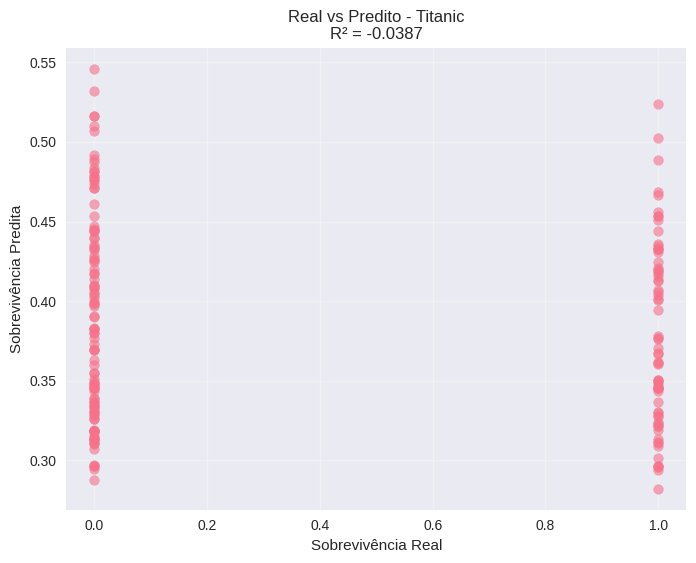

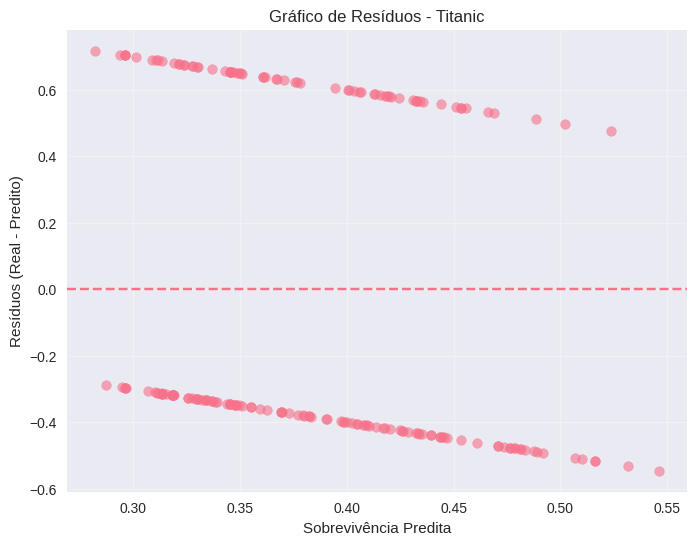

=== IMPORTÂNCIA DAS FEATURES ===
      Feature  Coefficient  Abs_Coefficient
0      Pclass    -0.046317         0.046317
1         Age     0.028240         0.028240
2       SibSp     0.022455         0.022455
9  Embarked_S     0.015144         0.015144
4        Fare    -0.012660         0.012660
5  FamilySize     0.012190         0.012190
7    Sex_male    -0.008220         0.008220
3       Parch    -0.007459         0.007459
6     IsAlone     0.007109         0.007109
8  Embarked_Q    -0.004064         0.004064


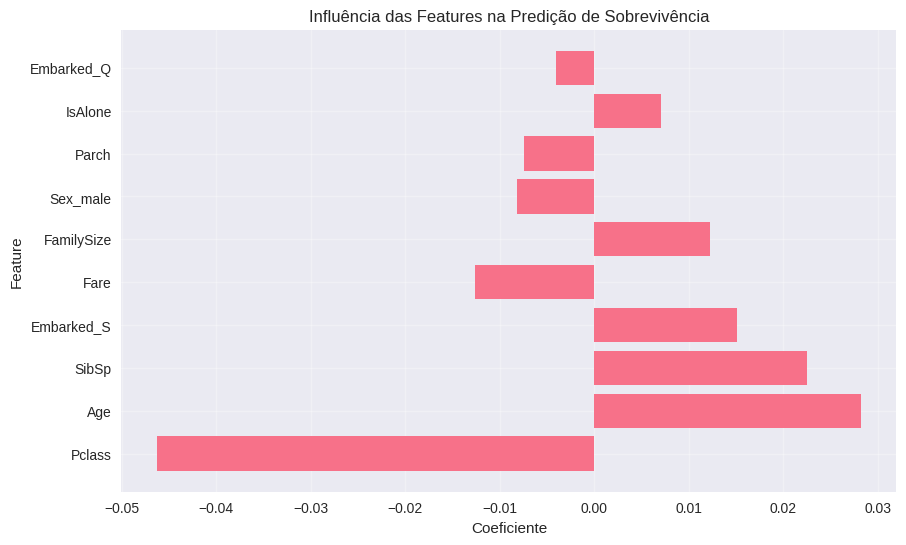

In [83]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.6
)

plt.xlabel('Sobrevivência Real')
plt.ylabel('Sobrevivência Predita')
plt.title(f'Real vs Predito - Titanic\nR² = {test_r2:.4f}')

plt.grid(True, alpha=0.3)

plt.show()

residuals = y_test - y_test_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Sobrevivência Predita')
plt.ylabel('Resíduos (Real - Predito)')
plt.title('Gráfico de Resíduos - Titanic')

plt.grid(True, alpha=0.3)

plt.show()

feature_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': model.coef_
})

feature_importance['Abs_Coefficient'] = (
    feature_importance['Coefficient'].abs()
)

feature_importance = feature_importance.sort_values(
    'Abs_Coefficient',
    ascending=False
)

print("=== IMPORTÂNCIA DAS FEATURES ===")
print(feature_importance)

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Coefficient']
)

plt.xlabel('Coeficiente')
plt.ylabel('Feature')
plt.title('Influência das Features na Predição de Sobrevivência')

plt.grid(True, alpha=0.3)

plt.show()

In [84]:
# Insights adicionais: Análise das features
print("=== ANÁLISE DETALHADA DAS FEATURES ===")
print("\nFeatures mais importantes (por valor absoluto do coeficiente):")
for i, row in feature_importance.head(3).iterrows():
    coef_value = row['Coefficient']
    feature_name = row['Feature']
    direction = "aumenta" if coef_value > 0 else "diminui"
    print(f"• {feature_name}: {abs(coef_value):.4f} - {nome_target} {direction} quando esta feature aumenta")

print(f"\nResumo da Performance do Modelo:")
print(f"• O modelo explica {test_r2*100:.1f}% da variância em {nome_target}")
print(f"• Erro médio de predição: {test_mae:.2f} {unidade_target}")
print(f"• Modelo pode prever {nome_target} dentro de ±{test_rmse:.2f} {unidade_target} em média")

print(f"\n=== EXEMPLO DE PREDIÇÃO ===")
sample_features = X_test_scaled.iloc[0:1]
sample_actual = y_test.iloc[0]
sample_prediction = model.predict(sample_features)[0]

print(f"Features da amostra (padronizadas):")
for feature, value in zip(sample_features.columns, sample_features.iloc[0]):
    print(f"  {feature}: {value:.2f}")
print(f"\n{nome_target} real: {sample_actual:.2f} {unidade_target}")
print(f"{nome_target} predito: {sample_prediction:.2f} {unidade_target}")
print(f"Erro de predição: {abs(sample_actual - sample_prediction):.2f} {unidade_target}")

=== ANÁLISE DETALHADA DAS FEATURES ===

Features mais importantes (por valor absoluto do coeficiente):
• Pclass: 0.0463 - Survived diminui quando esta feature aumenta
• Age: 0.0282 - Survived aumenta quando esta feature aumenta
• SibSp: 0.0225 - Survived aumenta quando esta feature aumenta

Resumo da Performance do Modelo:
• O modelo explica -3.9% da variância em Survived
• Erro médio de predição: 0.48 
• Modelo pode prever Survived dentro de ±0.50  em média

=== EXEMPLO DE PREDIÇÃO ===
Features da amostra (padronizadas):
  Pclass: 0.81
  Age: -0.09
  SibSp: 0.38
  Parch: 0.78
  Fare: -0.33
  FamilySize: 0.63
  IsAlone: -1.23
  Sex_male: 0.72
  Embarked_Q: -0.30
  Embarked_S: -1.69

Survived real: 0.00 
Survived predito: 0.32 
Erro de predição: 0.32 
